# 01 — DNN Baseline: Inverse Design of Underwater Acoustic Coatings

## Overview
This notebook implements the **baseline Deep Neural Network (DNN)** approach for inverse design of a 10-layer underwater acoustic metamaterial coating.

**Problem**: Given a desired average sound-absorption coefficient (1–1000 Hz), predict the 20 structural/material parameters that achieve it.

**Approach**: Two-phase training:
1. **Phase 1** — Train a *forward surrogate* NN (params → absorption) to serve as a differentiable physics proxy.
2. **Phase 2** — Train an *inverse* NN (absorption → params) with a **dual loss**: parameter-matching MSE + surrogate-based reconstruction MSE.

The dual loss is critical because the inverse mapping is one-to-many (many parameter sets can give the same absorption), so solely minimising parameter MSE is ill-posed.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---- Force NVIDIA GPU ----
assert torch.cuda.is_available(), (
    "CUDA not available! Install PyTorch with CUDA support:\n"
    "  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121"
)
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

GPU : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


## TMM Forward Model (pure NumPy)
Computes the average absorption coefficient (1–1000 Hz) for a 10-layer coating via the Transfer-Matrix Method.

In [3]:
# ---------- physical constants ----------
RHO_WATER = 1000.0   # kg/m^3
C_WATER   = 1500.0   # m/s
Z_WATER   = RHO_WATER * C_WATER
W_FILM    = 2.0      # unit-cell width in metres
HOLLOW_MAP = {1: 0, 2: 1, 4: 2, 5: 3, 7: 4, 8: 5}  # layer (0-idx) -> m-index

PARAM_COLUMNS = (
    [f'd{i}' for i in range(1, 11)] +
    ['m2', 'm3', 'm5', 'm6', 'm8', 'm9'] +
    ['rho', 'eta', 'E', 'nu']
)

PARAM_BOUNDS = np.array([
    [1.0, 20.0],    # d1  (mm)
    [1.0, 20.0],    # d2
    [1.0, 20.0],    # d3
    [1.0, 20.0],    # d4
    [1.0, 20.0],    # d5
    [1.0, 20.0],    # d6
    [1.0, 20.0],    # d7
    [1.0, 20.0],    # d8
    [1.0, 20.0],    # d9
    [1.0, 20.0],    # d10
    [20.0, 1980.0], # m2  (mm)
    [20.0, 1980.0], # m3
    [20.0, 1980.0], # m5
    [20.0, 1980.0], # m6
    [20.0, 1980.0], # m8
    [20.0, 1980.0], # m9
    [1000.0, 1500.0], # rho (kg/m^3)
    [0.1, 0.8],      # eta
    [1e7, 1e8],      # E   (Pa)
    [0.4, 0.49],     # nu
])


def tmm_forward(params):
    """
    Compute average absorption (1-1000 Hz) for a 10-layer coating.

    Parameters
    ----------
    params : array-like, shape (20,)
        [d1..d10 (mm), m2,m3,m5,m6,m8,m9 (mm), rho, eta, E, nu]

    Returns
    -------
    float  : average absorption coefficient
    """
    d_mm = np.asarray(params[:10], dtype=float)
    m_mm = np.asarray(params[10:16], dtype=float)
    rho_r = float(params[16])
    eta   = float(params[17])
    E_r   = float(params[18])
    nu    = float(params[19])

    d_m = d_mm / 1000.0
    m_m = m_mm / 1000.0

    E_complex = E_r * (1.0 + 1j * eta)
    lam = (E_complex * nu) / ((1 + nu) * (1 - 2*nu))
    mu  = E_complex / (2.0 * (1 + nu))

    alpha_sum = 0.0
    for f in range(1, 1001):
        omega = 2.0 * np.pi * f
        T = np.eye(2, dtype=complex)
        for i in range(10):
            d_i = d_m[i]
            if i in HOLLOW_MAP:
                eps = m_m[HOLLOW_MAP[i]] / W_FILM
            else:
                eps = 0.0
            rho_eff = rho_r * (1.0 - eps**2)
            num = mu*(lam + 2*mu)*(eps**2 + 1) + 2*eps**2*lam
            den = (lam + mu)*eps**2 + mu
            S_eff = num / den if abs(den) > 1e-15 else num * 1e15
            c_eff = np.sqrt(S_eff / rho_eff)
            k = omega / c_eff
            Z_eff = rho_eff * c_eff
            cos_kd = np.cos(k * d_i)
            sin_kd = np.sin(k * d_i)
            t21 = (1j * sin_kd / Z_eff) if abs(Z_eff) > 1e-15 else (1e15 + 0j)
            Ti = np.array([[cos_kd, 1j*Z_eff*sin_kd],
                           [t21,    cos_kd]], dtype=complex)
            T = T @ Ti
        if abs(T[1, 0]) < 1e-15:
            R = 1.0
        else:
            Z_in = T[0, 0] / T[1, 0]
            R = (Z_in - Z_WATER) / (Z_in + Z_WATER) if abs(Z_in) < 1e15 else 1.0
        a = 1.0 - abs(R)**2
        alpha_sum += max(0.0, min(1.0, a.real if hasattr(a, 'real') else a))
    return alpha_sum / 1000.0


# Quick sanity check with base-case params from the reference paper
_base = [10]*10 + [1000]*6 + [1130, 0.4, 5e7, 0.44]
print(f'Base-case average absorption: {tmm_forward(_base):.4f}')

Base-case average absorption: 0.3002


## Data Loading & Preprocessing

In [4]:
df = pd.read_csv('../data/lhs_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Absorption range: [{df["Average_Absorption"].min():.4f}, {df["Average_Absorption"].max():.4f}]')
df.head()

Dataset shape: (100000, 21)
Absorption range: [0.0467, 0.6842]


,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,...,m3,m5,m6,m8,m9,rho,eta,E,nu,Average_Absorption
0,4.071436,5.151032,10.858298,14.419719,5.659139,1.768199,19.314587,11.401355,17.904284,3.194731,...,911.415722,1285.024540,1821.401545,1141.232075,456.351399,1184.863998,0.363811,5.879209e+07,0.469327,0.340475
1,6.653044,8.777409,15.343470,9.463285,3.883857,5.634506,9.090517,15.674702,9.611830,17.297322,...,521.334760,1351.824133,585.122731,182.303470,469.878160,1350.308761,0.606339,4.623781e+07,0.434993,0.462129
2,4.002877,18.008727,15.430754,7.157367,8.217347,7.029184,14.330706,2.764388,6.646209,5.843788,...,898.271768,924.577733,1681.271012,123.885567,818.440999,1040.478651,0.229156,5.888348e+07,0.472955,0.201527
3,7.039548,16.589772,5.442216,4.239540,11.277338,15.265504,1.713498,19.004373,10.690875,3.429401,...,302.843557,1615.106596,1869.053018,1773.616871,1878.681471,1408.019035,0.378558,6.101366e+07,0.468468,0.240025
4,2.057868,2.492040,9.094042,17.902661,18.634872,6.812798,6.397911,11.600781,17.081930,15.612487,...,553.812529,990.987711,97.804533,709.314991,1320.467429,1399.165031,0.518751,8.542365e+07,0.450641,0.472426


In [5]:
param_cols = [c for c in df.columns if c != 'Average_Absorption']
X = df[param_cols].values  # (100000, 20)
y = df['Average_Absorption'].values  # (100000,)

# Train / Val / Test  =  80k / 10k / 10k
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

# Normalise parameters to [0, 1]
param_scaler = MinMaxScaler()
X_train_n = param_scaler.fit_transform(X_train)
X_val_n   = param_scaler.transform(X_val)
X_test_n  = param_scaler.transform(X_test)

# Normalise absorption to [0, 1]
abs_scaler = MinMaxScaler()
y_train_n = abs_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_n   = abs_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_n  = abs_scaler.transform(y_test.reshape(-1, 1)).ravel()

Train: 80000, Val: 10000, Test: 10000


In [6]:
def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=True, num_workers=0)

BS = 512
# Forward surrogate loaders: input=params, target=absorption
fwd_train_loader = make_loader(X_train_n, y_train_n, BS)
fwd_val_loader   = make_loader(X_val_n,   y_val_n,   BS, shuffle=False)

# Inverse model loaders: input=absorption, target=params
inv_train_loader = make_loader(y_train_n.reshape(-1, 1), X_train_n, BS)
inv_val_loader   = make_loader(y_val_n.reshape(-1, 1),   X_val_n,   BS, shuffle=False)

## Phase 1 — Forward Surrogate Model
A small NN that maps 20 normalised parameters → normalised absorption.  
Once trained and frozen, it serves as a differentiable physics proxy in the dual loss.

In [7]:
class ForwardSurrogate(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32),  nn.ReLU(),
            nn.Linear(32, 1),   nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


surrogate = ForwardSurrogate().to(device)
opt_s = optim.Adam(surrogate.parameters(), lr=1e-3, weight_decay=1e-5)
sched_s = optim.lr_scheduler.ReduceLROnPlateau(opt_s, factor=0.5, patience=10)
criterion = nn.MSELoss()

surr_train_losses, surr_val_losses = [], []

print('Training forward surrogate ...')
for epoch in range(1, 101):
    surrogate.train()
    running = 0.0
    for xb, yb in fwd_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = surrogate(xb)
        loss = criterion(pred, yb)
        opt_s.zero_grad(); loss.backward(); opt_s.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(fwd_train_loader.dataset)

    surrogate.eval()
    val_run = 0.0
    with torch.no_grad():
        for xb, yb in fwd_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_run += criterion(surrogate(xb), yb).item() * xb.size(0)
    val_loss = val_run / len(fwd_val_loader.dataset)
    sched_s.step(val_loss)

    surr_train_losses.append(train_loss)
    surr_val_losses.append(val_loss)
    if epoch % 20 == 0:
        print(f'  Epoch {epoch:3d}  train={train_loss:.6f}  val={val_loss:.6f}')

# Freeze surrogate
for p in surrogate.parameters():
    p.requires_grad = False
surrogate.eval()
print('Forward surrogate trained and frozen.')

Training forward surrogate ...
  Epoch  20  train=0.000390  val=0.000375
  Epoch  40  train=0.000289  val=0.000476
  Epoch  60  train=0.000242  val=0.000232
  Epoch  80  train=0.000196  val=0.000236
  Epoch 100  train=0.000193  val=0.000215
Forward surrogate trained and frozen.


In [8]:
# Surrogate accuracy check
with torch.no_grad():
    y_pred_s = surrogate(torch.tensor(X_val_n, dtype=torch.float32).to(device)).cpu().numpy()
print(f'Surrogate val R^2 = {r2_score(y_val_n, y_pred_s):.4f}')

Surrogate val R^2 = 0.9946


## Phase 2 — Inverse DNN with Dual Loss

In [9]:
class InverseDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),   nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128), nn.Dropout(0.1),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128), nn.Dropout(0.1),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128),
            nn.Linear(128, 20),  nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


inverse_model = InverseDNN().to(device)
opt_inv = optim.Adam(inverse_model.parameters(), lr=1e-3, weight_decay=1e-5)
sched_inv = optim.lr_scheduler.ReduceLROnPlateau(opt_inv, factor=0.5, patience=10)

ALPHA = 0.7  # weight for parameter loss
EPOCHS = 200
PATIENCE = 20

inv_train_losses, inv_val_losses = [], []
best_val, patience_ctr = float('inf'), 0
best_state = None

print('Training inverse DNN (dual loss) ...')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    inverse_model.train()
    running = 0.0
    for ab_batch, param_batch in inv_train_loader:
        ab_batch, param_batch = ab_batch.to(device), param_batch.to(device)
        pred_params = inverse_model(ab_batch)

        loss_param = criterion(pred_params, param_batch)
        recon_abs  = surrogate(pred_params)
        loss_recon = criterion(recon_abs, ab_batch.squeeze(-1))
        loss = ALPHA * loss_param + (1 - ALPHA) * loss_recon

        opt_inv.zero_grad(); loss.backward(); opt_inv.step()
        running += loss.item() * ab_batch.size(0)
    train_loss = running / len(inv_train_loader.dataset)

    inverse_model.eval()
    val_run = 0.0
    with torch.no_grad():
        for ab_b, p_b in inv_val_loader:
            ab_b, p_b = ab_b.to(device), p_b.to(device)
            pp = inverse_model(ab_b)
            vl = ALPHA * criterion(pp, p_b) + (1 - ALPHA) * criterion(surrogate(pp), ab_b.squeeze(-1))
            val_run += vl.item() * ab_b.size(0)
    val_loss = val_run / len(inv_val_loader.dataset)
    sched_inv.step(val_loss)

    inv_train_losses.append(train_loss)
    inv_val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        patience_ctr = 0
        best_state = {k: v.cpu().clone() for k, v in inverse_model.state_dict().items()}
    else:
        patience_ctr += 1

    if epoch % 20 == 0:
        print(f'  Epoch {epoch:3d}  train={train_loss:.6f}  val={val_loss:.6f}')
    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

train_time = time.time() - t0
inverse_model.load_state_dict(best_state)
inverse_model.eval()
print(f'Training done in {train_time:.1f}s.  Best val loss: {best_val:.6f}')

Training inverse DNN (dual loss) ...
  Epoch  20  train=0.055559  val=0.055345
  Epoch  40  train=0.055533  val=0.055347
  Epoch  60  train=0.055527  val=0.055326
  Early stopping at epoch 72
Training done in 299.7s.  Best val loss: 0.055322


## Evaluation on Test Set

In [10]:
with torch.no_grad():
    pred_params_n = inverse_model(
        torch.tensor(y_test_n.reshape(-1, 1), dtype=torch.float32).to(device)
    ).cpu().numpy()

# Metrics in normalised space
param_mse = mean_squared_error(X_test_n, pred_params_n)
param_mae = mean_absolute_error(X_test_n, pred_params_n)
param_r2  = r2_score(X_test_n, pred_params_n)

print(f'Parameter-space  MSE={param_mse:.6f}  MAE={param_mae:.6f}  R²={param_r2:.4f}')

Parameter-space  MSE=0.079104  MAE=0.240790  R²=0.0493


## Physics Validation
Denormalise the predicted parameters, run TMM, and compare the reconstructed absorption to the target.

In [11]:
N_VAL = 200  # how many test samples to validate through TMM
pred_params_phys = param_scaler.inverse_transform(pred_params_n[:N_VAL])
target_abs = y_test[:N_VAL]

recon_abs = np.array([tmm_forward(p) for p in pred_params_phys])

recon_mse = mean_squared_error(target_abs, recon_abs)
recon_mae = mean_absolute_error(target_abs, recon_abs)
recon_r2  = r2_score(target_abs, recon_abs)
print(f'Reconstruction  MSE={recon_mse:.6f}  MAE={recon_mae:.6f}  R²={recon_r2:.4f}')

Reconstruction  MSE=0.000017  MAE=0.003269  R²=0.9990


## Visualisation

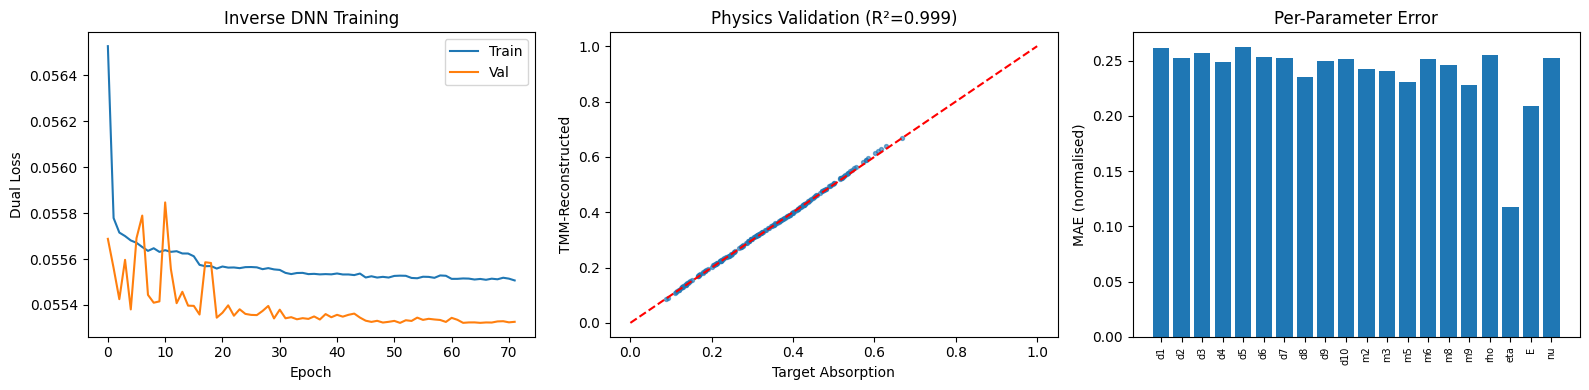

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Training curves
ax = axes[0]
ax.plot(inv_train_losses, label='Train')
ax.plot(inv_val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dual Loss')
ax.set_title('Inverse DNN Training')
ax.legend()

# 2) Reconstruction scatter
ax = axes[1]
ax.scatter(target_abs, recon_abs, s=8, alpha=0.6)
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel('Target Absorption'); ax.set_ylabel('TMM-Reconstructed')
ax.set_title(f'Physics Validation (R²={recon_r2:.3f})')

# 3) Per-parameter MAE
ax = axes[2]
per_param_mae = np.abs(X_test_n[:N_VAL] - pred_params_n[:N_VAL]).mean(axis=0)
ax.bar(range(20), per_param_mae)
ax.set_xticks(range(20))
ax.set_xticklabels(PARAM_COLUMNS, rotation=90, fontsize=7)
ax.set_ylabel('MAE (normalised)')
ax.set_title('Per-Parameter Error')

plt.tight_layout()
plt.show()

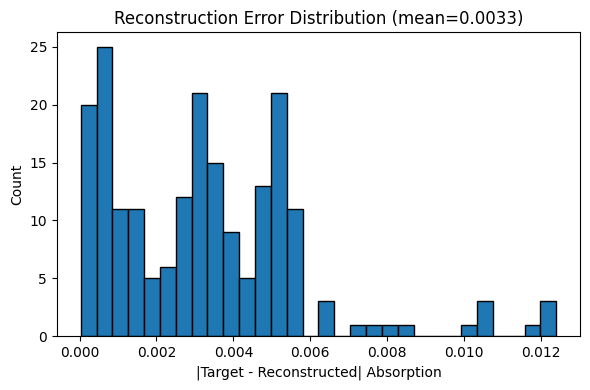

In [13]:
# Reconstruction error histogram
errors = np.abs(target_abs - recon_abs)
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=30, edgecolor='k')
plt.xlabel('|Target - Reconstructed| Absorption')
plt.ylabel('Count')
plt.title(f'Reconstruction Error Distribution (mean={errors.mean():.4f})')
plt.tight_layout()
plt.show()

In [14]:
# Example case studies
print('Sample predictions (first 5):')
print(f'{"Target":>10s} {"Reconstructed":>14s} {"Error":>10s}')
for i in range(5):
    print(f'{target_abs[i]:10.4f} {recon_abs[i]:14.4f} {errors[i]:10.4f}')

Sample predictions (first 5):
    Target  Reconstructed      Error
    0.1411         0.1435     0.0024
    0.2969         0.3018     0.0050
    0.3161         0.3210     0.0049
    0.4178         0.4177     0.0001
    0.3100         0.3150     0.0051


## Results Summary

In [15]:
results = {
    'method': 'DNN_Baseline',
    'param_mse': float(param_mse),
    'param_mae': float(param_mae),
    'param_r2':  float(param_r2),
    'recon_mse': float(recon_mse),
    'recon_mae': float(recon_mae),
    'recon_r2':  float(recon_r2),
    'can_generate_diverse': False,
    'training_time_seconds': round(train_time, 1),
}
print(results)

{'method': 'DNN_Baseline', 'param_mse': 0.07910366114877464, 'param_mae': 0.2407899284764917, 'param_r2': 0.0492945336277464, 'recon_mse': 1.7013903277620146e-05, 'recon_mae': 0.0032691292516943537, 'recon_r2': 0.9990382316134826, 'can_generate_diverse': False, 'training_time_seconds': 299.7}


### How to Read These Results

**The parameter-space R² (~0.05) looks bad — but that's fine!**  
The inverse problem is fundamentally **one-to-many**: hundreds of different 20-parameter combinations can produce the same absorption value. So the ML model doesn't need to recover the *exact same* parameters from the dataset — it just needs to find *any* valid set of parameters that produces the target absorption.

**The reconstruction R² (~0.999) is the real measure of success.**  
This means: when we take the ML's predicted 20 parameters and plug them into the exact TMM physics equations, the resulting absorption matches the target to within ~0.003 on average. The model is successfully doing inverse design.

**Validation Pipeline:**
```
User gives: target absorption (e.g., 0.30)
    ↓
ML predicts: 20 design parameters [d1..d10, m2..m9, ρ, η, E, ν]
    ↓
TMM physics: computes actual absorption from those 20 params
    ↓
Compare: TMM absorption ≈ 0.30 ± 0.003  ✓
```

**Limitation**: This model produces only **one** design per target. Generative approaches (VAE, Diffusion, INN) in later notebooks can produce **multiple** diverse valid designs.